In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

os.environ['PATH'] = os.environ['XILINX_HLS'] + '/bin:' + os.environ['PATH']
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

2026-07-26 16:22:45.520266: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-26 16:22:45.781758: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-26 16:22:45.781816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-26 16:22:45.839972: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-26 16:22:45.950646: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-26 16:22:45.952006: I tensorflow/core/platform/cpu_feature_guard.cc:1

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-07-26 16:22:46.861205: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
data = fetch_openml(name="diabetes", version=7, parser="auto")
X, y = data['data'], data['target']

In [3]:
print(data['feature_names'])
print(X.shape, y.shape)
print(X[:5])
print(y[:5])

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
(768, 8) (768,)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6       98             58             33      190  34.0   
1            2      112             75             32        0  35.7   
2            2      108             64              0        0  30.8   
3            8      107             80              0        0  24.6   
4            7      136             90              0        0  29.9   

   DiabetesPedigreeFunction  Age  
0                     0.430   43  
1                     0.148   21  
2                     0.158   21  
3                     0.856   34  
4                     0.210   50  
0    No
1    No
2    No
3    No
4    No
Name: TestedPositiveForDiabetes, dtype: category
Categories (2, object): ['No', 'Yes']


In [4]:
# Define the columns where 0 means "missing"
columns_with_hidden_missing_values = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Check and print the zeros before processing
zeros_before = (X[columns_with_hidden_missing_values] == 0).sum()
print("--- ZEROS BEFORE PROCESSING ---")
print(zeros_before)

# Make an explicit copy of X 
X = X.copy()

# Run the loop to replace 0s with the column averages
for col in columns_with_hidden_missing_values:
    # Tell pandas to treat this column as decimals so it doesn't freak out
    X[col] = X[col].astype(float) 
    
    # Replace the 0s
    X.loc[:, col] = X[col].replace(0, np.nan)
    X.loc[:, col] = X[col].fillna(X[col].mean())

# Check and print the zeros after processing
zeros_after = (X[columns_with_hidden_missing_values] == 0).sum()
print("\n--- ZEROS AFTER PROCESSING ---")
print(zeros_after)

--- ZEROS BEFORE PROCESSING ---
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

--- ZEROS AFTER PROCESSING ---
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [5]:
le = LabelEncoder()
y = le.fit_transform(y)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y[:5])


[0 0 0 0 0]


In [6]:
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)
print("Our test is inbalanced since diabetes to non diabetes ratio is 2:1")
print(np.bincount(y_train_val))

Our test is inbalanced since diabetes to non diabetes ratio is 2:1
[404 210]


In [7]:
np.save('X_train_val.npy', X_train_val)
np.save('X_test.npy', X_test)
np.save('y_train_val.npy', y_train_val)
np.save('y_test.npy', y_test)
np.save('classes.npy', le.classes_)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from callbacks import all_callbacks
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score

In [9]:
model = Sequential()

model.add(Dense(64, input_shape=(8,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.001)))
model.add(BatchNormalization())
model.add(Activation(activation='relu', name='relu1'))
model.add(Dropout(0.2))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dropout(0.2))

model.add(Dense(1, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.001)))

model.add(Activation(activation='sigmoid', name='sigmoid'))

In [10]:
train = True
if train:
    adam = Adam(learning_rate=0.001)
 
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True
    )

    weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_val), y=y_train_val)
    class_weights_dict = dict(enumerate(weights))
    
    model.compile(optimizer=adam, loss='binary_crossentropy', metrics=['accuracy'])    
    
    hls_callbacks = all_callbacks(
        stop_patience=50,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='model_1',
    )
    
    hls_callbacks.callbacks.append(early_stop)
    
    model.fit(
        X_train_val,
        y_train_val,
        batch_size=128,
        epochs=2000,
        validation_split=0.25,
        shuffle=True,
        callbacks=hls_callbacks.callbacks, 
        class_weight=class_weights_dict
    ) 

else:
    from tensorflow.keras.models import load_model
    
    model = load_model('model_1/KERAS_check_best_model.keras')

# Generate the predictions before trying to calculate the accuracy
y_keras = model.predict(X_test)
y_pred = (y_keras > 0.5).astype(int).ravel()

print("Final accuracy:", accuracy_score(y_test, y_pred))

Epoch 1/2000
1/4 [======>.......................] - ETA: 1s - loss: 1.2508 - accuracy: 0.4219
***callbacks***
saving losses to model_1/losses.log

Epoch 1: val_loss improved from inf to 1.11045, saving model to model_1/KERAS_check_best_model.h5

Epoch 1: val_loss improved from inf to 1.11045, saving model to model_1/KERAS_check_best_model_weights.h5

Epoch 1: saving model to model_1/KERAS_check_model_last.h5

Epoch 1: saving model to model_1/KERAS_check_model_last_weights.h5

***callbacks end***

4/4 [==============================] - 1s 60ms/step - loss: 1.1743 - accuracy: 0.4761 - val_loss: 1.1105 - val_accuracy: 0.4221 - lr: 0.0010
Epoch 2/2000
1/4 [======>.......................] - ETA: 0s - loss: 1.1230 - accuracy: 0.4922WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0010s vs `on_train_batch_end` time: 0.0022s). Check your callbacks.

***callbacks***
saving losses to model_1/losses.log

Epoch 2: val_loss improved from 1.11

/home/tvangos/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 3: saving model to model_1/KERAS_check_model_last.h5

Epoch 3: saving model to model_1/KERAS_check_model_last_weights.h5

***callbacks end***

4/4 [==============================] - 0s 44ms/step - loss: 1.0725 - accuracy: 0.6022 - val_loss: 1.0181 - val_accuracy: 0.6948 - lr: 0.0010
Epoch 4/2000
1/4 [======>.......................] - ETA: 0s - loss: 1.0399 - accuracy: 0.6016
***callbacks***
saving losses to model_1/losses.log

Epoch 4: val_loss improved from 1.01813 to 0.98355, saving model to model_1/KERAS_check_best_model.h5

Epoch 4: val_loss improved from 1.01813 to 0.98355, saving model to model_1/KERAS_check_best_model_weights.h5

Epoch 4: saving model to model_1/KERAS_check_model_last.h5

Epoch 4: saving model to model_1/KERAS_check_model_last_weights.h5

***callbacks end***

4/4 [==============================] - 0s 20ms/step - loss: 1.0089 - accuracy: 0.6739 - val_loss: 0.9836 - val_accuracy: 0.7727 - lr: 0.0010
Epoch 5/2000
1/4 [======>.......................] - ETA: 0

In [11]:
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='model', backend='Vitis')
config['Part'] = 'xcu250-figd2104-2L-e'
print("-----------------------------------")
print("Configuration")
print("-----------------------------------")

config['Model']['ReuseFactor'] = 32
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='model_1/hls4ml_prj', part='xcu250-figd2104-2L-e'
)

-----------------------------------
Configuration
-----------------------------------


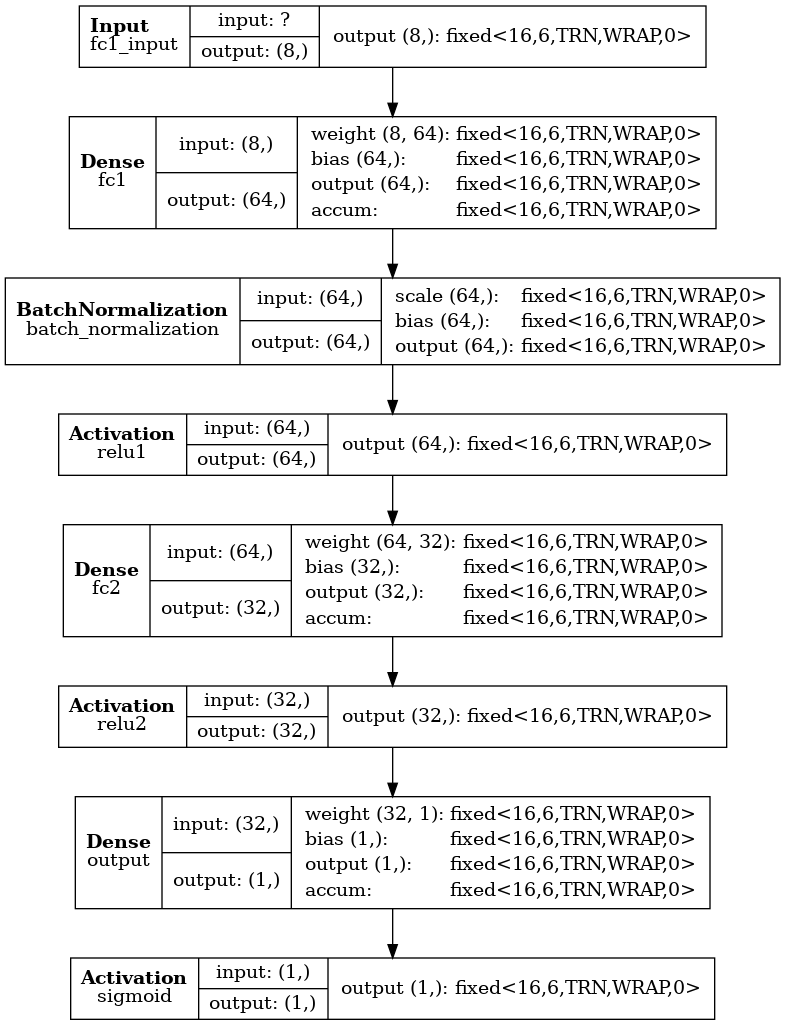

In [12]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [13]:
hls_model.compile()
y_keras = model.predict(X_test)
y_hls = hls_model.predict(np.ascontiguousarray(X_test))

5/5 [==============================] - 0s 733us/step


5/5 [==============================] - 0s 728us/step
Keras  Accuracy: 0.7857142857142857
hls4ml Accuracy: 0.7792207792207793


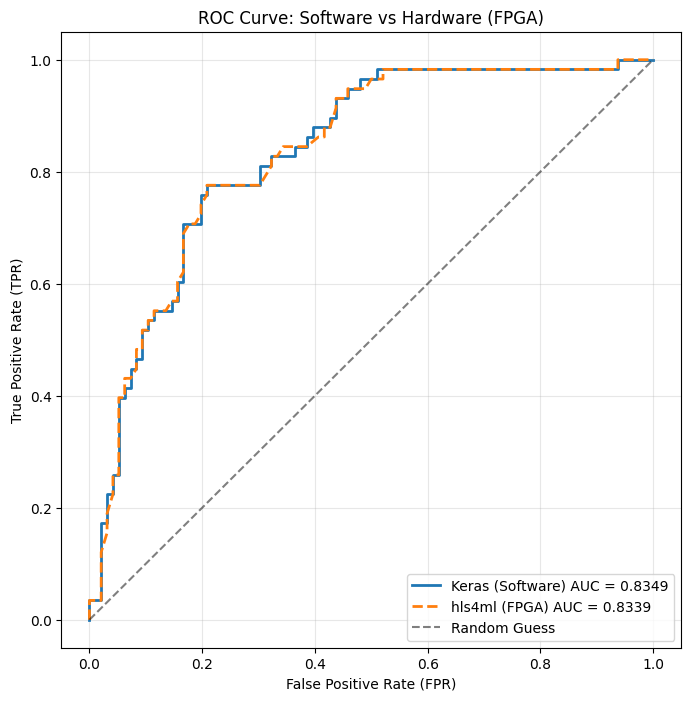

In [14]:
import plotting 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score

# Print the Accuracies
y_keras = model.predict(X_test)
print("Keras  Accuracy: {}".format(accuracy_score(y_test, (y_keras > 0.5).astype(int).ravel())))
print("hls4ml Accuracy: {}".format(accuracy_score(y_test, (y_hls > 0.5).astype(int).ravel())))

# Calculate ROC and AUC for the Keras model
fpr_keras, tpr_keras, _ = roc_curve(y_test, y_keras.ravel())
roc_auc_keras = auc(fpr_keras, tpr_keras)

# Calculate ROC and AUC for the hls4ml model
fpr_hls, tpr_hls, _ = roc_curve(y_test, y_hls.ravel())
roc_auc_hls = auc(fpr_hls, tpr_hls)

# Plot both curves together
plt.figure(figsize=(8, 8)) 

# Plot Keras curve
plt.plot(fpr_keras, tpr_keras, label=f"Keras (Software) AUC = {roc_auc_keras:.4f}", linewidth=2)

# Plot hls4ml curve
plt.plot(fpr_hls, tpr_hls, label=f"hls4ml (FPGA) AUC = {roc_auc_hls:.4f}", linestyle='--', linewidth=2)

# Plot the random guess baseline
plt.plot([0,1], [0,1], 'k--', label="Random Guess", alpha=0.5)

# Formatting the plot
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve: Software vs Hardware (FPGA)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
hls_model.build(csim=False)


****** vitis-run v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /home/tvangos/Desktop/UTH/CPU_design/src/model_1/hls4ml_prj/build_prj.tcl -work_dir /home/tvangos/Desktop/UTH/CPU_design/src/model_1/hls4ml_prj

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.647',
  'BestLatency': '91',
  'WorstLatency': '91',
  'IntervalMin': '31',
  'IntervalMax': '31',
  'BRAM_18K': '1',
  'DSP': '83',
  'FF': '24115',
  'LUT': '73157',
  'URAM': '0',
  'AvailableBRAM_18K': '5376',
  'AvailableDSP': '12288',
  'AvailableFF': '3456000',
  'AvailableLUT': '1728000',
  'AvailableURAM': '1280'}}

In [16]:
hls4ml.report.read_vivado_report('model_1/hls4ml_prj/')

Found 1 solution(s) in model_1/hls4ml_prj//myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Sun Jul 26 16:24:15 2026

* Version:        2023.2 (Build 4023990 on Oct 11 2023)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu250-figd2104-2L-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.647 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +---------+---------+------